In [ ]:
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import os
from pathlib import Path
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import pathlib
import seaborn as sns


# EDA

In [3]:
df = pd.read_csv('HAM10000_metadata.csv')

# Create diagnosis_group column
benign_labels = ['nv', 'bkl', 'df', 'vasc']
df['diagnosis_group'] = df['dx'].apply(lambda x: 'Benign' if x in benign_labels else 'Malignant')

# Display first 5 rows
display(df.head())

,lesion_id,image_id,dx,dx_type,age,sex,localization,diagnosis_group
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,Benign
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,Benign
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,Benign
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,Benign
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,Benign


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   lesion_id        10015 non-null  object 
 1   image_id         10015 non-null  object 
 2   dx               10015 non-null  object 
 3   dx_type          10015 non-null  object 
 4   age              9958 non-null   float64
 5   sex              10015 non-null  object 
 6   localization     10015 non-null  object 
 7   diagnosis_group  10015 non-null  object 
dtypes: float64(1), object(7)
memory usage: 626.1+ KB


In [7]:
print("\nDiagnosis value counts:")
print(df['dx'].value_counts())



Diagnosis value counts:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [8]:
print("\nDiagnosis group counts:")
print(df['diagnosis_group'].value_counts())


Diagnosis group counts:
diagnosis_group
Benign       8061
Malignant    1954
Name: count, dtype: int64


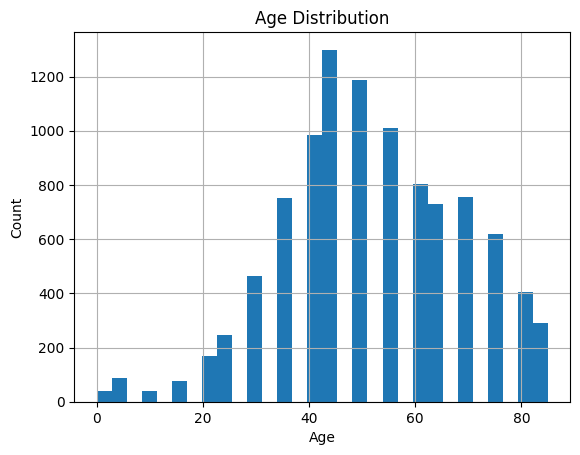

In [9]:
plt.figure()
df['age'].hist(bins=30)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()


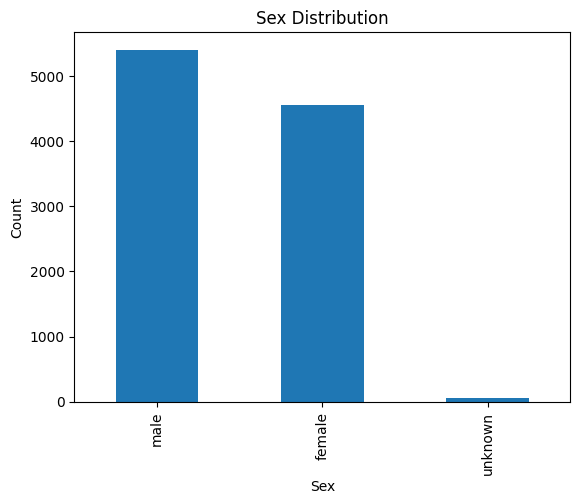

In [10]:
# Plot sex distribution
plt.figure()
df['sex'].value_counts().plot(kind='bar')
plt.title('Sex Distribution')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.show()

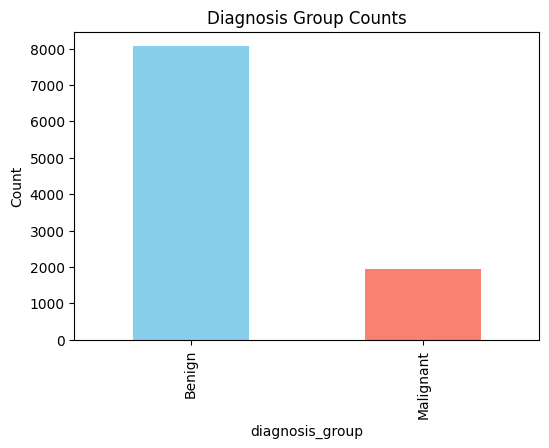

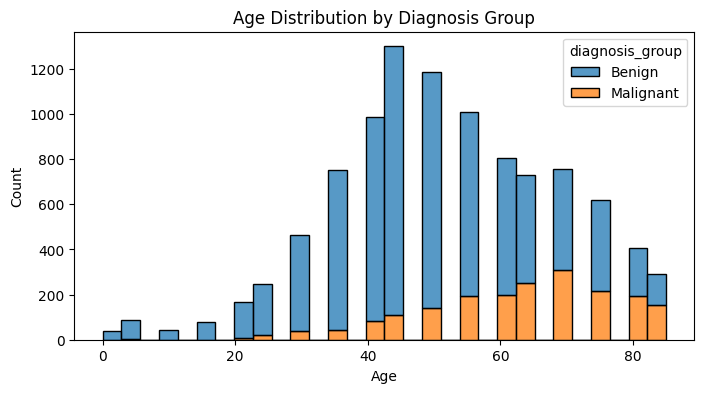

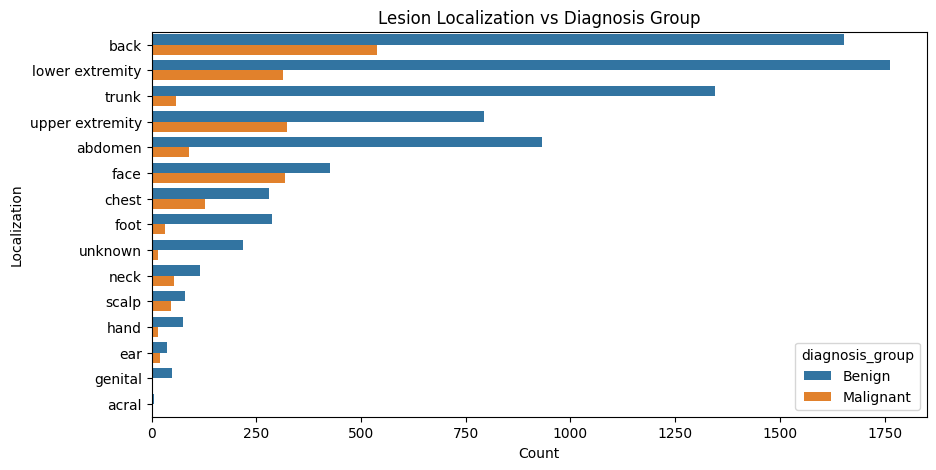


Missing values:
lesion_id           0
image_id            0
dx                  0
dx_type             0
age                57
sex                 0
localization        0
diagnosis_group     0
dtype: int64


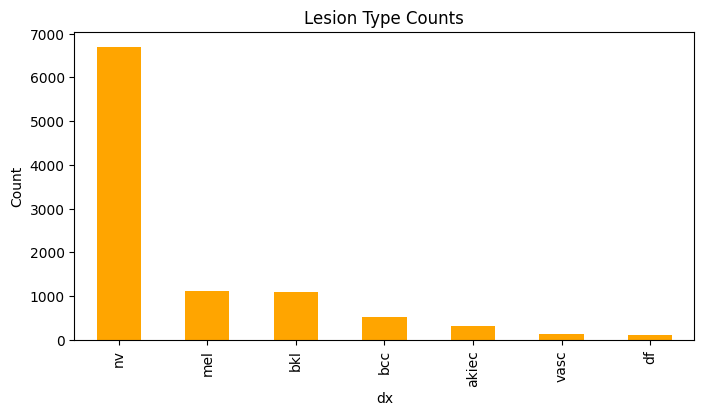


Summary statistics for age:
count    9958.000000
mean       51.863828
std        16.968614
min         0.000000
25%        40.000000
50%        50.000000
75%        65.000000
max        85.000000
Name: age, dtype: float64

Sex distribution:
sex
male       5406
female     4552
unknown      57
Name: count, dtype: int64


In [52]:
# Load data
df = pd.read_csv('HAM10000_metadata.csv')
benign_labels = ['nv', 'bkl', 'df', 'vasc']
df['diagnosis_group'] = df['dx'].apply(lambda x: 'Benign' if x in benign_labels else 'Malignant')

# Diagnosis group balance
plt.figure(figsize=(6, 4))
df['diagnosis_group'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Diagnosis Group Counts')
plt.ylabel('Count')
plt.show()

# Age distribution by group
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='age', hue='diagnosis_group', multiple='stack', bins=30)
plt.title('Age Distribution by Diagnosis Group')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

# Lesion localization vs. diagnosis group
plt.figure(figsize=(10, 5))
sns.countplot(data=df, y='localization', hue='diagnosis_group', order=df['localization'].value_counts().index)
plt.title('Lesion Localization vs Diagnosis Group')
plt.xlabel('Count')
plt.ylabel('Localization')
plt.show()

# Missing data check
print("\nMissing values:")
print(df.isnull().sum())

# RGB color histograms (example for a few images if you have images loaded)
# Skipping full image loading here—can add if needed!

# Lesion types breakdown
plt.figure(figsize=(8, 4))
df['dx'].value_counts().plot(kind='bar', color='orange')
plt.title('Lesion Type Counts')
plt.ylabel('Count')
plt.show()

# Summary statistics
print("\nSummary statistics for age:")
print(df['age'].describe())

print("\nSex distribution:")
print(df['sex'].value_counts())


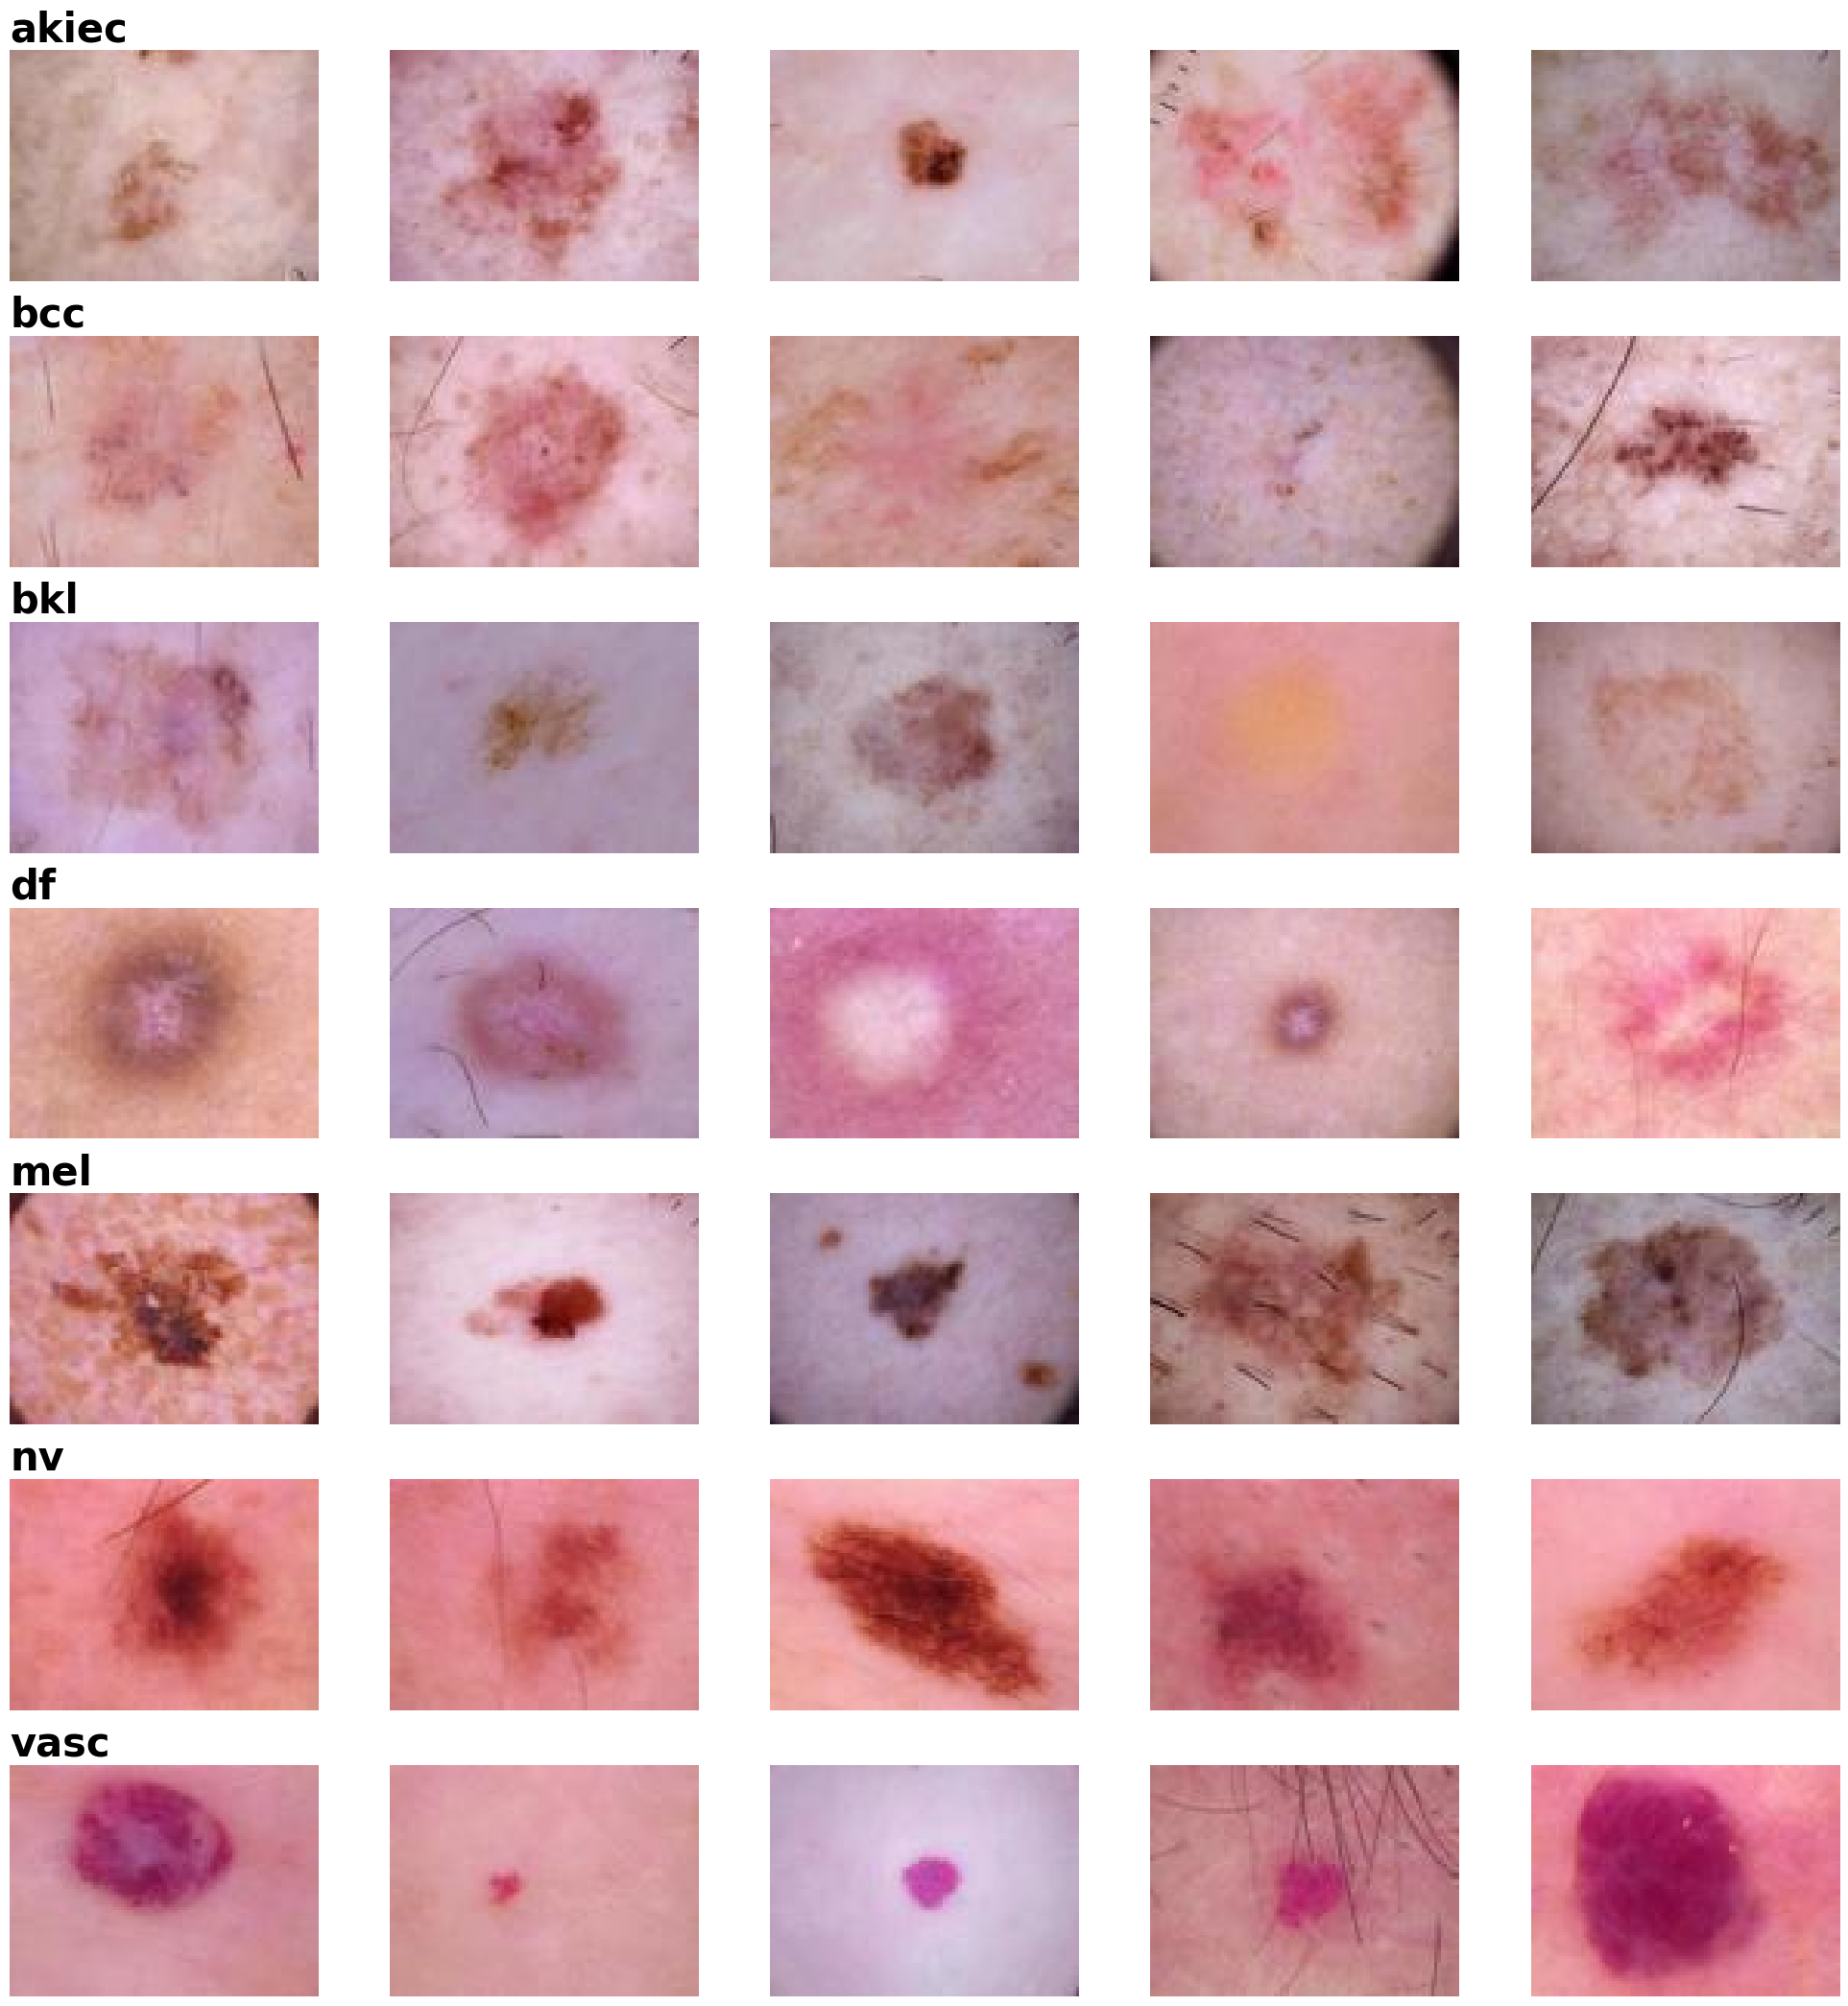

In [34]:

# Path to main folder
main_folder = r'C:\Users\LENOVO\OneDrive - Asia Pacific University\Desktop\Assinments APU\sem3\project\Project_AI\HAM10000_images'
subfolders = os.listdir(main_folder)

# Number of samples per class
n_samples = 5

fig, m_axs = plt.subplots(len(subfolders), n_samples, figsize=(4*n_samples, 3*len(subfolders)))

for ax_row, folder_name in zip(m_axs, subfolders):
    folder_path = os.path.join(main_folder, folder_name)
    images = os.listdir(folder_path)
    
    # Row label, set bigger font size
    ax_row[0].set_title(folder_name, fontsize=30, loc='left', fontweight='bold')
    
    sample_images = images[:n_samples]
    for ax, img_name in zip(ax_row, sample_images):
        img_path = os.path.join(folder_path, img_name)
        img = Image.open(img_path)
        ax.imshow(img)
        ax.axis('off')

plt.tight_layout()
plt.show()


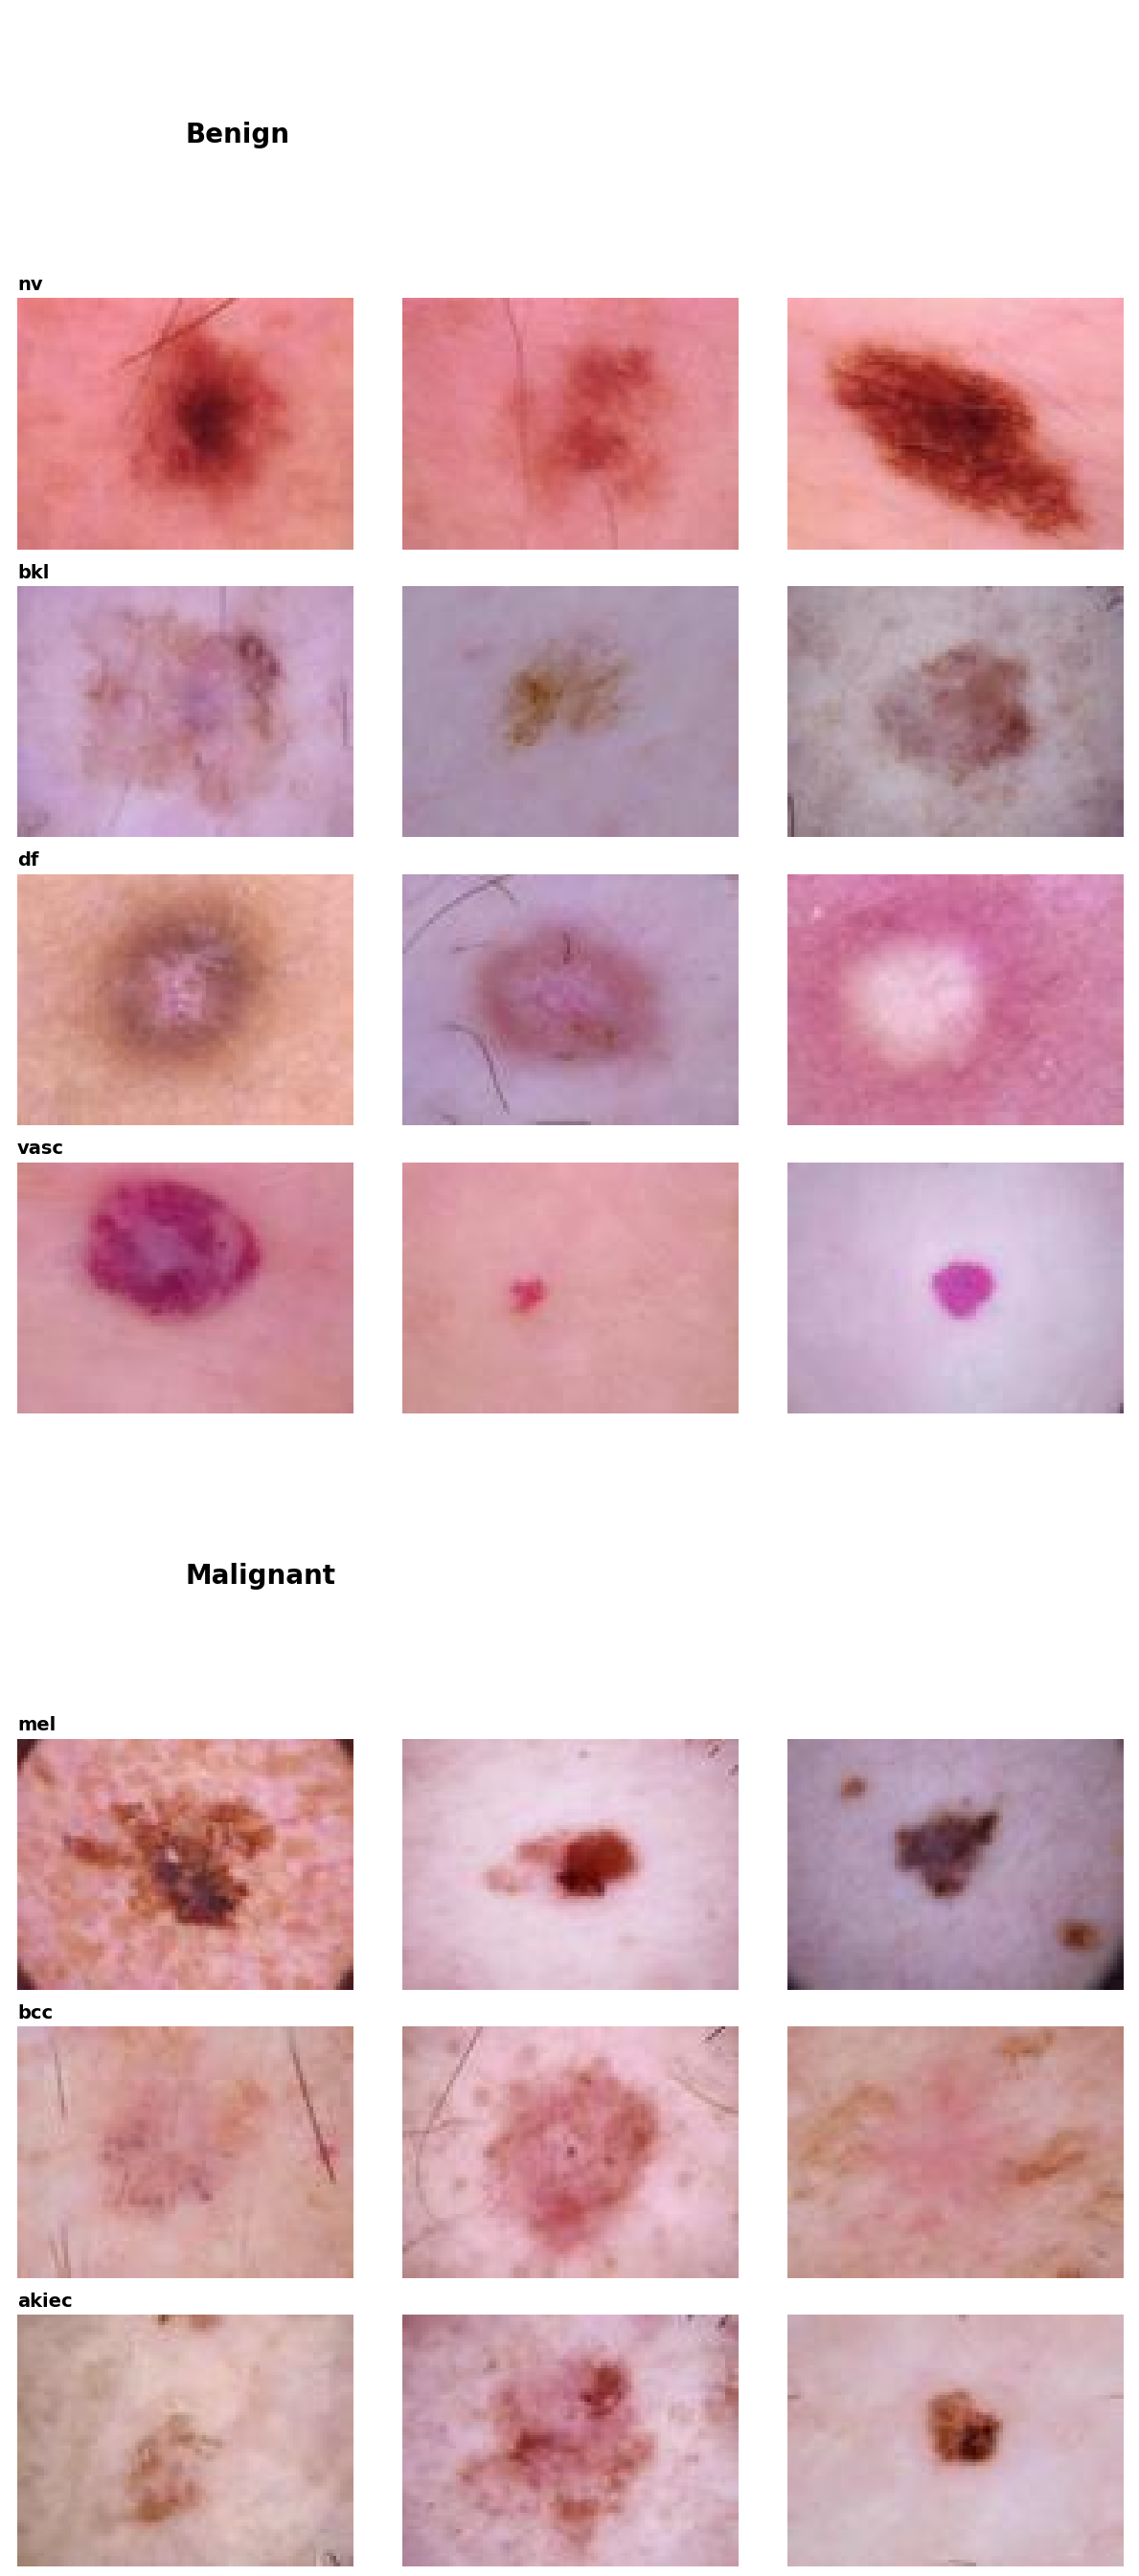

In [36]:
# Group them
benign_folders = ['nv', 'bkl', 'df', 'vasc']
malignant_folders = ['mel', 'bcc', 'akiec']
groups = {'Benign': benign_folders, 'Malignant': malignant_folders}

# Number of samples to show from each subtype
n_samples = 3

# Rows: total of 2 group titles + number of subtypes
total_rows = 2 + len(benign_folders) + len(malignant_folders)
fig, m_axs = plt.subplots(total_rows, n_samples, figsize=(4*n_samples, 3*total_rows))

row_idx = 0
for group_name, folders in groups.items():
    # Group row title
    for col in range(n_samples):
        ax = m_axs[row_idx, col]
        ax.axis('off')
        if col == 0:
            ax.text(0.5, 0.5, group_name, ha='left', va='center', fontsize=20, fontweight='bold', transform=ax.transAxes)
    row_idx += 1
    
    # Show images for each subtype
    for folder in folders:
        folder_path = os.path.join(main_folder, folder)
        images = os.listdir(folder_path)[:n_samples]  # first few images
        for col_idx in range(n_samples):
            ax = m_axs[row_idx, col_idx]
            if col_idx < len(images):
                img = Image.open(os.path.join(folder_path, images[col_idx]))
                ax.imshow(img)
                ax.axis('off')
                if col_idx == 0:
                    ax.set_title(folder, fontsize=14, fontweight='bold', loc='left')
            else:
                ax.axis('off')
        row_idx += 1

plt.tight_layout()
plt.show()


C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


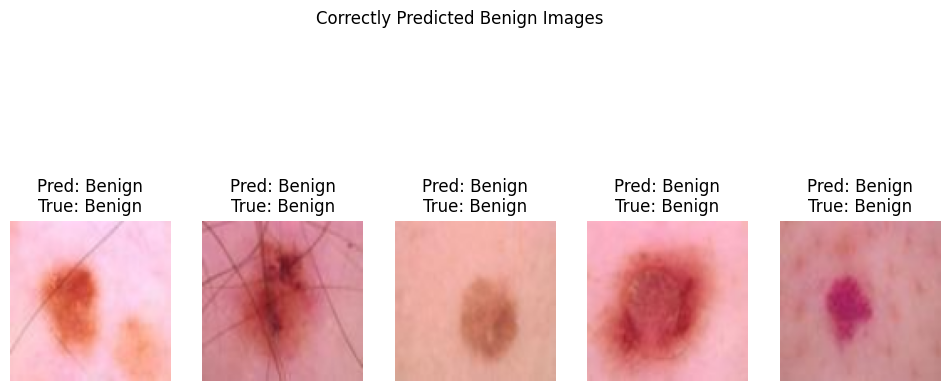

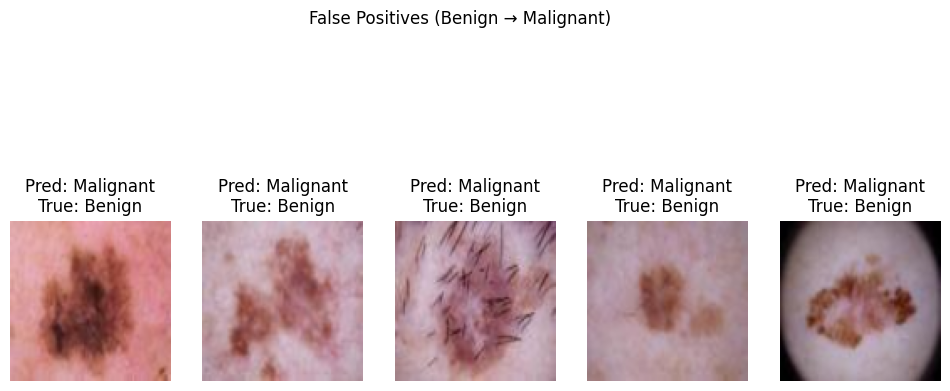

In [53]:
# Load metadata
df_bal = pd.read_csv('HAM10000_metadata.csv')
benign_labels = ['nv', 'bkl', 'df', 'vasc']
df_bal['diagnosis_group'] = df_bal['dx'].apply(lambda x: 'Benign' if x in benign_labels else 'Malignant')

# Image paths
image_folder = r'C:\Users\LENOVO\OneDrive - Asia Pacific University\Desktop\Assinments APU\sem3\project\Project_AI\HAM10000_images'
img_root = pathlib.Path(image_folder)
all_paths = list(img_root.rglob("*.jpg"))
id2path = {p.stem: p for p in all_paths}
df_bal['path'] = df_bal['image_id'].map(id2path)
df_bal = df_bal.dropna(subset=['path']).reset_index(drop=True)

# Load images
def load_images(paths, img_size=(96, 96)):
    imgs = []
    for p in paths:
        img = cv2.imread(str(p))
        img = cv2.resize(img, img_size)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        imgs.append(img)
    return np.array(imgs, dtype=np.float32) / 255.0

X = load_images(df_bal['path'].tolist())
y = df_bal['diagnosis_group'].map({'Benign': 0, 'Malignant': 1}).values

# Split data
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42)

# Load model and predict
val_test_datagen = ImageDataGenerator(rescale=1./255)
test_gen = val_test_datagen.flow(X_test, y_test, shuffle=False)
model = keras.models.load_model('best_cnn_model.keras')

y_pred_probs = model.predict(test_gen, verbose=0).flatten()
y_pred = (y_pred_probs > 0.56).astype("int32")

# Identify correct and false positive indices
correct = np.where(y_pred == y_test)[0]
correct_benign = correct[np.where(y_test[correct] == 0)[0]]
false_positive = np.where((y_pred == 1) & (y_test == 0))[0]

# Function to plot images
def plot_predictions(indices, title):
    plt.figure(figsize=(12, 6))
    for i, idx in enumerate(indices[:5]):
        img = X_test[idx]
        pred_label = 'Malignant' if y_pred[idx] == 1 else 'Benign'
        true_label = 'Malignant' if y_test[idx] == 1 else 'Benign'
        plt.subplot(1, 5, i+1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Pred: {pred_label}\nTrue: {true_label}")
    plt.suptitle(title)
    plt.show()

# Show the plots
plot_predictions(correct_benign, "Correctly Predicted Benign Images")
plot_predictions(false_positive, "False Positives (Benign → Malignant)")


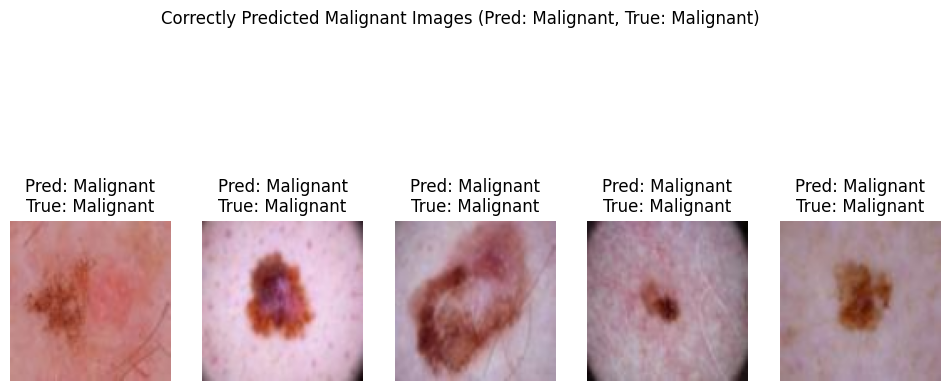

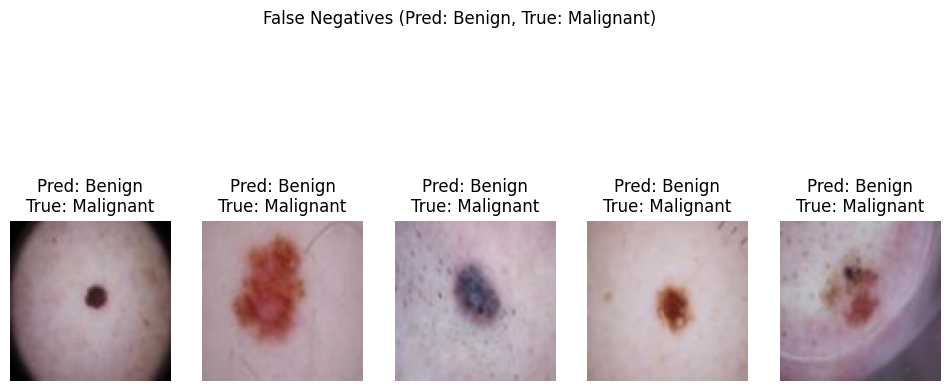

In [54]:

y_true = y_test

# Correctly predicted malignant indices
correct = np.where(y_pred == y_true)[0]
correct_malignant = correct[np.where(y_true[correct] == 1)[0]]

# False negatives: predicted benign (0) but actually malignant (1)
false_negative = np.where((y_pred == 0) & (y_true == 1))[0]

# Plot function
def plot_predictions(indices, title):
    plt.figure(figsize=(12, 6))
    for i, idx in enumerate(indices[:5]):  # show 5 images
        img = X_test[idx]
        pred_label = 'Malignant' if y_pred[idx] == 1 else 'Benign'
        true_label = 'Malignant' if y_true[idx] == 1 else 'Benign'
        plt.subplot(1, 5, i+1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Pred: {pred_label}\nTrue: {true_label}")
    plt.suptitle(title)
    plt.show()

# Show correctly predicted malignant images
plot_predictions(correct_malignant, "Correctly Predicted Malignant Images (Pred: Malignant, True: Malignant)")

# Show false negatives (malignant → benign)
plot_predictions(false_negative, "False Negatives (Pred: Benign, True: Malignant)")
